#colab notebook

In [1]:
pip install ortools numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.7/27.7 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 25.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.31.1 which is incompatibl

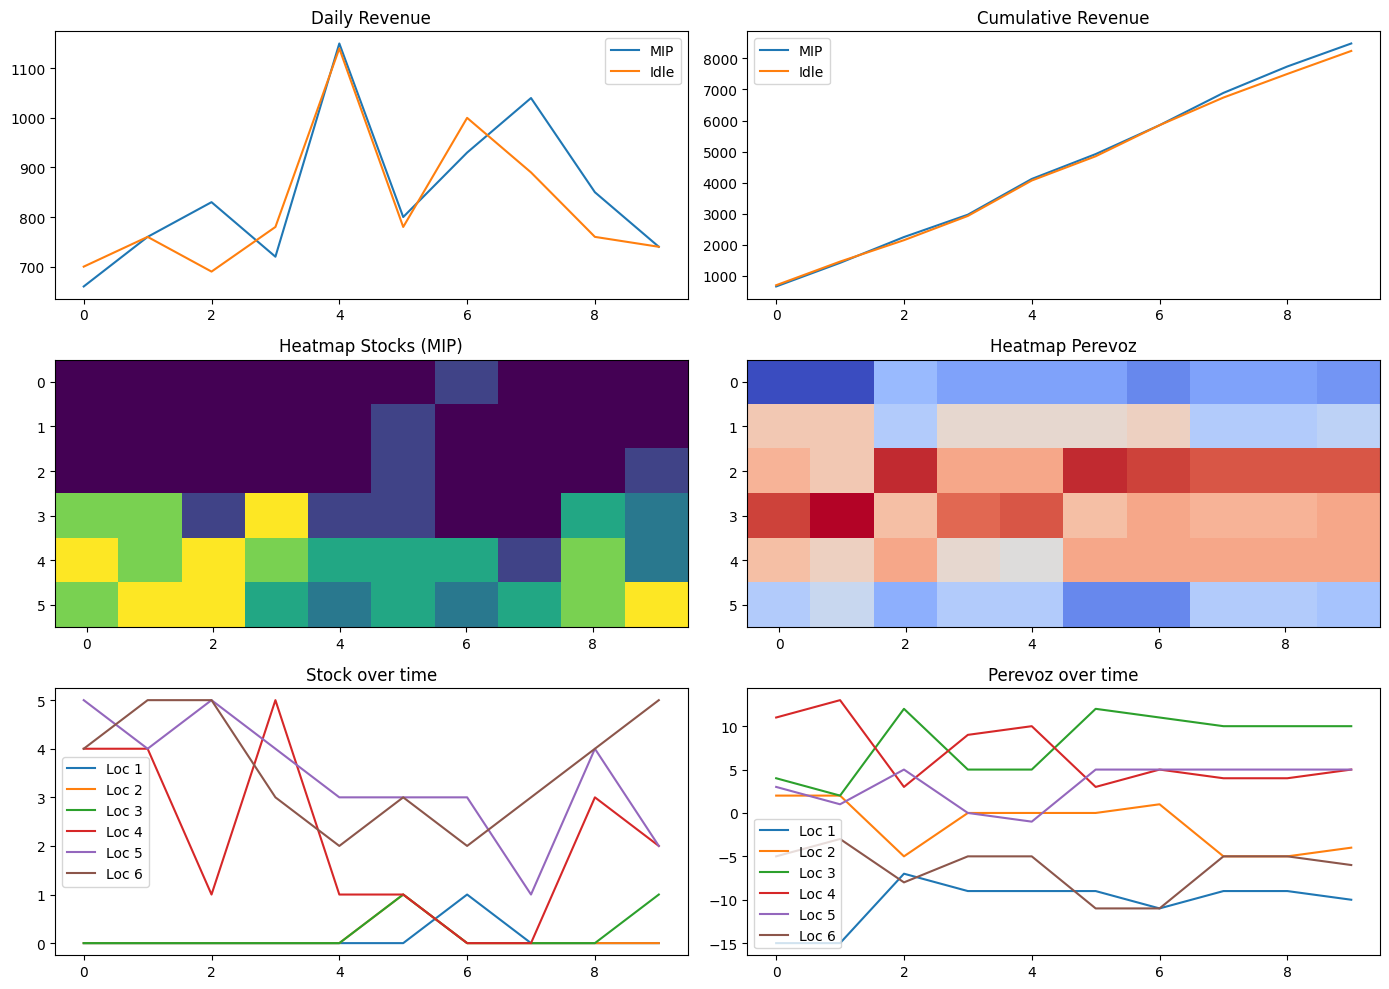

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ortools.sat.python import cp_model

# ---------------- Параметры ----------------
I = 6
S = 30
M = 5
lambda_rent = 3
p = 10
c_move = 1
days = 10

# Подобранные lambda_i для явной выгоды от перемещений
lambdas = [10, 8, 6, 4, 2, 1]  # спрос выше в начале, ниже в конце

# Матрица расстояний (линейная карта)
Dmat = np.zeros((I, I), dtype=int)
for i in range(I):
    for j in range(I):
        Dmat[i, j] = abs(i - j)

# Матрица возвратов RETURN(i,j)
RETURN = np.zeros((I, I))
for i in range(I):
    RETURN[i, i] = 0.2
    for j in range(I):
        if i != j:
            RETURN[i, j] = 0.8 / (I - 1)

# ---------------- Функция для предвычисления прибыли ----------------
def precompute_rik(K):
    r_ik = np.zeros((I, K + 1))
    for i in range(I):
        for k in range(K + 1):
            trials = np.random.poisson(lambdas[i], size=5000)
            exp_min = np.mean(np.minimum(trials, k))
            r_ik[i, k] = p * exp_min
    return r_ik

# ---------------- Решение MIP ----------------
def solve_mip(s_available, K):
    model = cp_model.CpModel()
    y = {}
    perevoz = {}
    for i in range(I):
        for k in range(K + 1):
            y[i, k] = model.NewBoolVar(f'y_{i}_{k}')
        for j in range(I):
            if i != j:
                perevoz[i, j] = model.NewIntVar(-M, M, f'p_{i}_{j}')
    for i in range(I):
        model.Add(sum(y[i, k] for k in range(K + 1)) == 1)
        model.Add(sum(k * y[i, k] for k in range(K + 1)) ==
                  s_available[i] + sum(perevoz[j, i] for j in range(I) if j != i) -
                  sum(perevoz[i, j] for j in range(I) if j != i))
    for i in range(I):
        for j in range(I):
            if i != j:
                model.AddAbsEquality(model.NewIntVar(0, M, ''), perevoz[i, j])
    model.Add(sum(sum(perevoz[i, j] for j in range(I) if j != i) for i in range(I)) == 0)
    r_ik = precompute_rik(K)
    move_cost = sum(Dmat[i, j] * perevoz[i, j] for i in range(I) for j in range(I) if i != j)
    revenue = sum(r_ik[i, k] * y[i, k] for i in range(I) for k in range(K + 1))
    model.Maximize(revenue - c_move * move_cost)
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 10
    status = solver.Solve(model)
    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        res_perevoz = np.zeros((I, I), dtype=int)
        x_final = np.zeros(I, dtype=int)
        for i in range(I):
            for j in range(I):
                if i != j:
                    res_perevoz[i, j] = solver.Value(perevoz[i, j])
            for k in range(K + 1):
                if solver.Value(y[i, k]) == 1:
                    x_final[i] = k
        return res_perevoz, x_final
    else:
        print("MIP infeasible — no moves made")
        return np.zeros((I, I), dtype=int), np.array(s_available)

# ---------------- Симуляция ----------------
def simulate():
    cars_available = np.full(I, S // I)
    in_rent = [[] for _ in range(I)]
    revenues_MIP = []
    revenues_idle = []
    cum_MIP = []
    cum_idle = []
    stock_history_MIP = []
    stock_history_idle = []
    perevoz_history = []
    cum_r_MIP = 0
    cum_r_idle = 0
    K = max(S, max(cars_available))
    for day in range(days):
        cars_today_MIP = cars_available.copy()
        cars_today_idle = cars_available.copy()
        perevoz, target_MIP = solve_mip(cars_today_MIP, K)
        moves_out = np.sum(np.abs(perevoz), axis=1)
        # simulate rentals for MIP
        rev_MIP = 0
        for loc in range(I):
            demand = np.random.poisson(lambdas[loc])
            rent_count = min(cars_today_MIP[loc], demand)
            for _ in range(rent_count):
                dur = 1 + np.random.poisson(lambda_rent)
                dest = np.random.choice(I, p=RETURN[loc])
                in_rent[dest].append(dur)
                rev_MIP += p * dur
            cars_today_MIP[loc] -= rent_count
        # simulate rentals for idle
        rev_idle = 0
        for loc in range(I):
            demand = np.random.poisson(lambdas[loc])
            rent_count = min(cars_today_idle[loc], demand)
            for _ in range(rent_count):
                dur = 1 + np.random.poisson(lambda_rent)
                dest = np.random.choice(I, p=RETURN[loc])
                in_rent[dest].append(dur)
                rev_idle += p * dur
            cars_today_idle[loc] -= rent_count
        cum_r_MIP += rev_MIP
        cum_r_idle += rev_idle
        revenues_MIP.append(rev_MIP)
        revenues_idle.append(rev_idle)
        cum_MIP.append(cum_r_MIP)
        cum_idle.append(cum_r_idle)
        stock_history_MIP.append(cars_today_MIP.copy())
        stock_history_idle.append(cars_today_idle.copy())
        perevoz_history.append(np.sum(perevoz, axis=1))
    return (revenues_MIP, revenues_idle, cum_MIP, cum_idle,
            stock_history_MIP, stock_history_idle, perevoz_history)

# ---------------- Запуск и графики ----------------
res = simulate()
revenues_MIP, revenues_idle, cum_MIP, cum_idle, stock_MIP, stock_idle, perevoz_hist = res

fig, axs = plt.subplots(3, 2, figsize=(14, 10))
axs[0, 0].plot(revenues_MIP, label='MIP')
axs[0, 0].plot(revenues_idle, label='Idle')
axs[0, 0].set_title('Daily Revenue')
axs[0, 0].legend()
axs[0, 1].plot(cum_MIP, label='MIP')
axs[0, 1].plot(cum_idle, label='Idle')
axs[0, 1].set_title('Cumulative Revenue')
axs[0, 1].legend()
axs[1, 0].imshow(np.array(stock_MIP).T, aspect='auto', cmap='viridis')
axs[1, 0].set_title('Heatmap Stocks (MIP)')
axs[1, 1].imshow(np.array(perevoz_hist).T, aspect='auto', cmap='coolwarm')
axs[1, 1].set_title('Heatmap Perevoz')
for i in range(I):
    axs[2, 0].plot([s[i] for s in stock_MIP], label=f'Loc {i+1}')
    axs[2, 1].plot([p[i] for p in perevoz_hist], label=f'Loc {i+1}')
axs[2, 0].set_title('Stock over time')
axs[2, 1].set_title('Perevoz over time')
axs[2, 0].legend()
axs[2, 1].legend()
plt.tight_layout()
plt.show()
